# 02: Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Pipeline

Preprocessing runs as a script (`scripts/02_preprocess.py`). Preferably running in GPU (it can take more than 4 hours in GPU).

For each LSM file:
1. Read spectral tile (substack 1 = actual time-lapse data)
2. Phasor unmixing: 32 spectral channels -> 7 dye components (LipiBlue, 342, BODIPY, pHrodo, TMRM, Lyso, Tubulin)
3. Cellpose segmentation (GPU) → cell masks
4. 512×512 crop per cell, masked to remove neighbours



To run, first pick a free GPU with nvidia-smi, then:

```bash
CUDA_VISIBLE_DEVICES=1 nohup python scripts/02_preprocess.py > preprocess.log 2>&1 &
```

Output: `/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor/`
- `{name}_cells.npy` — (N_cells, 7, 512, 512)
- `{name}_cells_meta.csv` — cell_id, sample, group, tile, time, cell_label

## Preprocessed files summary

In [ ]:
OUT_DIR = Path("/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor")
DYE_LIST = ['LipiBlue', '342', 'BODIPY', 'pHrodo', 'TMRM', 'Lyso', 'Tubulin']

rows = []
for npy in sorted(OUT_DIR.glob("*_cells.npy")):
    name = npy.stem.replace("_cells", "")
    cells = np.load(npy, mmap_mode='r')
    meta = pd.read_csv(OUT_DIR / f"{name}_cells_meta.csv")
    rows.append({
        "file": name,
        "group": meta["group"].iloc[0],
        "cells": len(meta),
        "tiles": meta["tile"].nunique(),
        "timepoints": meta["time"].nunique(),
        "shape": str(cells.shape),
        "size_GB": f"{npy.stat().st_size / 1e9:.1f}",
    })

df_summary = pd.DataFrame(rows)
df_summary

,file,group,cells,tiles,timepoints,shape,size_GB
0,CNTL-MB231,Control,5415,25,15,"(5415, 7, 512, 512)",79.5
1,CNTL_2,Control,255,9,1,"(255, 7, 512, 512)",3.7
2,CNTL_75uM_p1,Control,10368,9,24,"(10368, 7, 512, 512)",152.2
3,CNTL_75uM_p2,Control,2424,9,24,"(2424, 7, 512, 512)",35.6
4,CNTL_75uM_p3,Control,4128,9,24,"(4128, 7, 512, 512)",60.6
5,CNTL_75uM_p4,Control,2160,9,24,"(2160, 7, 512, 512)",31.7
6,CNTL,Control,496,9,1,"(496, 7, 512, 512)",7.3
7,TAMO-MB231,Chemoresistant,4305,25,15,"(4305, 7, 512, 512)",63.2
8,TAMO_p1,Chemoresistant,11880,25,24,"(11880, 7, 512, 512)",174.4
9,TAMO_p2,Chemoresistant,10464,25,24,"(10464, 7, 512, 512)",153.6


In [ ]:
print(f"Total: {df_summary['cells'].astype(int).sum()} cells, "
      f"{df_summary['size_GB'].astype(float).sum():.0f} GB")

Total: 51895 cells, 762 GB


## Example cell crops

Each cell is a (7, 512, 512) array — one 512×512 image per dye channel, masked.

In [ ]:
cells = np.load(OUT_DIR / "CNTL-MB231_cells.npy", mmap_mode='r')
meta = pd.read_csv(OUT_DIR / "CNTL-MB231_cells_meta.csv")
print(f"CNTL-MB231: {cells.shape}")
meta.head()

CNTL-MB231: (5415, 7, 512, 512)
Metadata columns: ['cell_id', 'sample', 'group', 'tile', 'time', 'cell_label']


,cell_id,sample,group,tile,time,cell_label
0,0,CNTL-MB231,Control,0,0,1
1,1,CNTL-MB231,Control,0,0,2
2,2,CNTL-MB231,Control,0,0,3
3,3,CNTL-MB231,Control,0,0,4
4,4,CNTL-MB231,Control,0,0,5


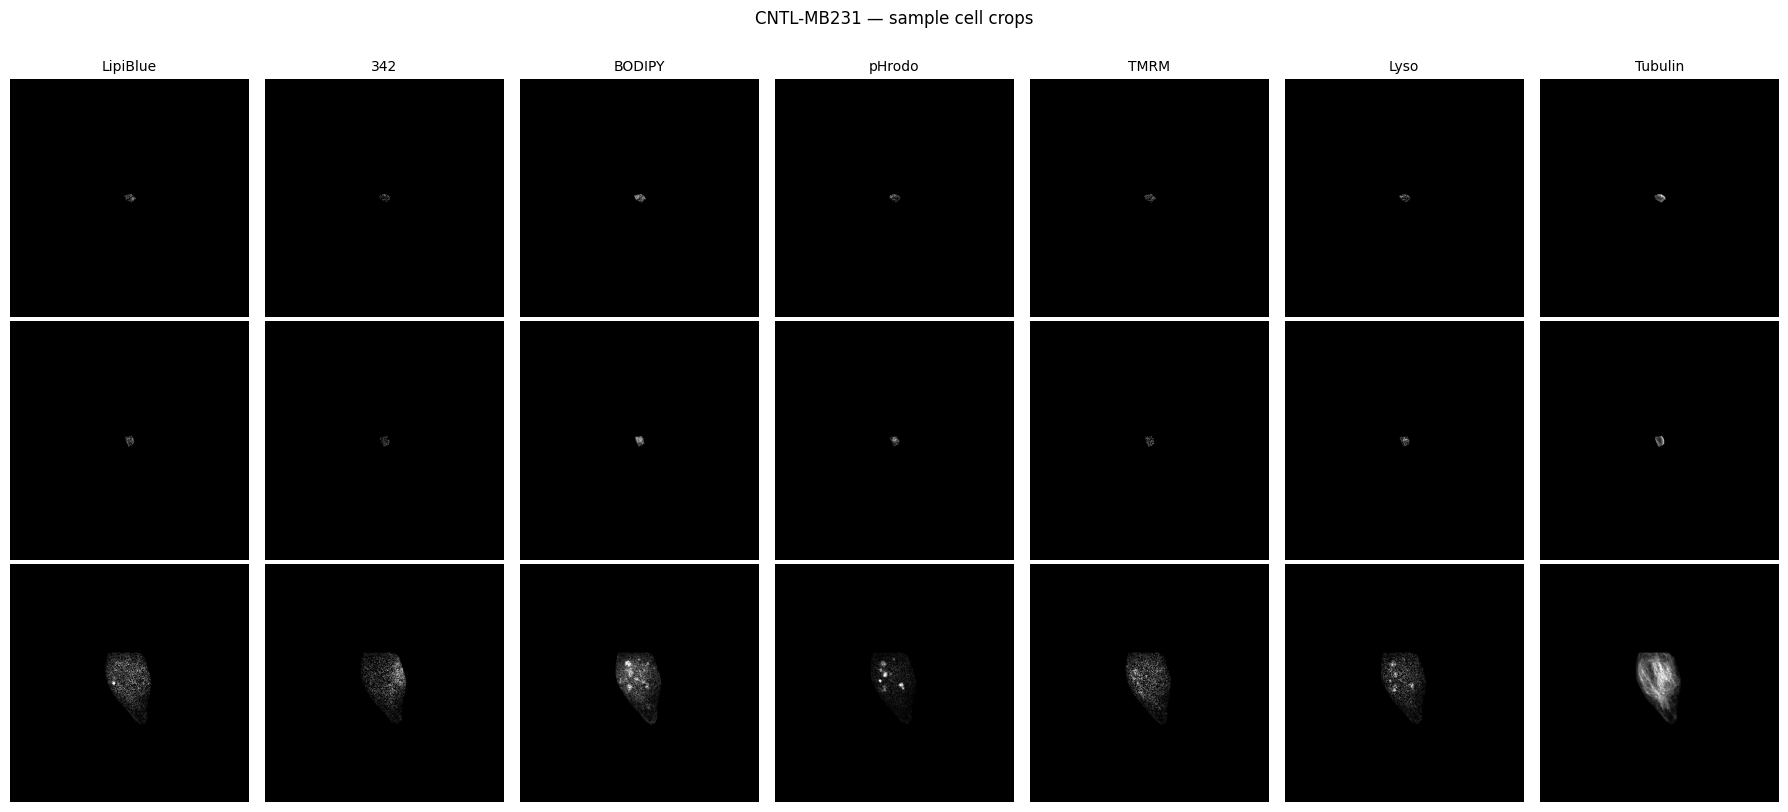

In [ ]:
rng = np.random.default_rng(42)
idx = rng.choice(len(cells), 3, replace=False)

fig, axes = plt.subplots(3, 7, figsize=(18, 8))
for row, i in enumerate(idx):
    for ch in range(7):
        img = cells[i, ch]
        vmax = np.percentile(img[img > 0], 99) if img.max() > 0 else 1
        axes[row, ch].imshow(img, cmap="gray", vmin=0, vmax=vmax)
        axes[row, ch].axis("off")
        if row == 0:
            axes[row, ch].set_title(DYE_LIST[ch], fontsize=10)

plt.suptitle("CNTL-MB231 — sample crops", y=1.01)
plt.tight_layout()

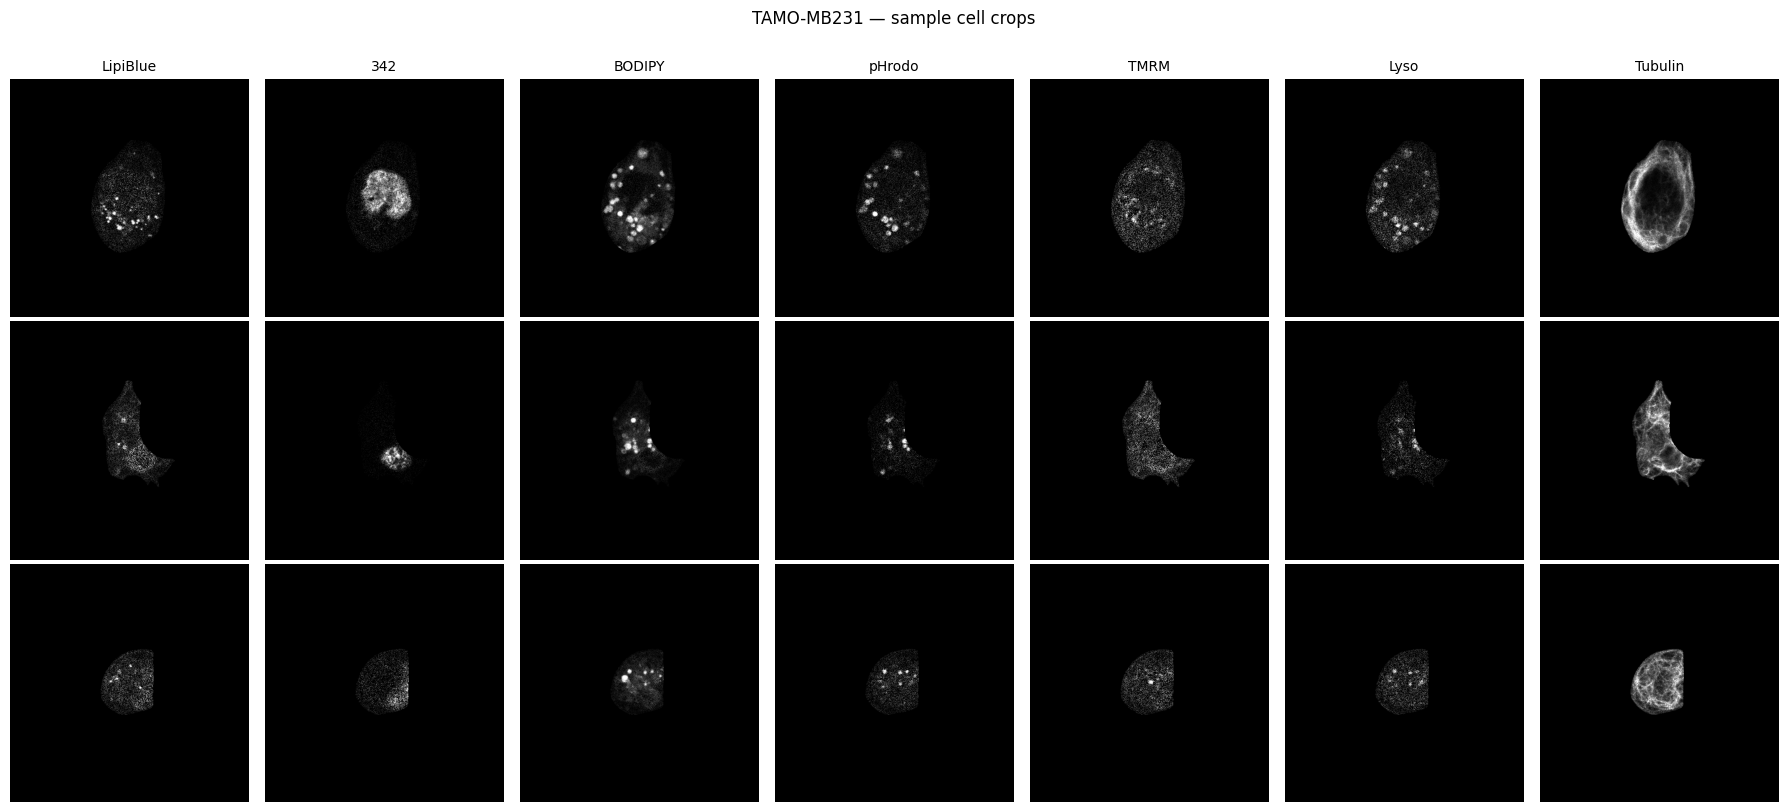

In [ ]:
cells_tamo = np.load(OUT_DIR / "TAMO-MB231_cells.npy", mmap_mode='r')
idx = rng.choice(len(cells_tamo), 3, replace=False)

fig, axes = plt.subplots(3, 7, figsize=(18, 8))
for row, i in enumerate(idx):
    for ch in range(7):
        img = cells_tamo[i, ch]
        vmax = np.percentile(img[img > 0], 99) if img.max() > 0 else 1
        axes[row, ch].imshow(img, cmap="gray", vmin=0, vmax=vmax)
        axes[row, ch].axis("off")
        if row == 0:
            axes[row, ch].set_title(DYE_LIST[ch], fontsize=10)

plt.suptitle("TAMO-MB231 — sample crops", y=1.01)
plt.tight_layout()